### Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
from plotly.express import scatter
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

### Get the data

In [2]:
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/demand.csv"
df = pd.read_csv(url)
df

,ID,Store ID,Total Price,Base Price,Units Sold
0,1,8091,99.0375,111.8625,20
1,2,8091,99.0375,99.0375,28
2,3,8091,133.9500,133.9500,19
3,4,8091,133.9500,133.9500,44
4,5,8091,141.0750,141.0750,52
...,...,...,...,...,...
150145,212638,9984,235.8375,235.8375,38
150146,212639,9984,235.8375,235.8375,30
150147,212642,9984,357.6750,483.7875,31
150148,212643,9984,141.7875,191.6625,12


### Data Preprocessing

check for null values

In [3]:
df.isna().sum()

ID             0
Store ID       0
Total Price    1
Base Price     0
Units Sold     0
dtype: int64

There is only one row that has a missing value. Since the dataset has more than 150k rows, it is simple to just drop that one row with the missing value.

In [4]:
df_final = df.dropna()
df_final

,ID,Store ID,Total Price,Base Price,Units Sold
0,1,8091,99.0375,111.8625,20
1,2,8091,99.0375,99.0375,28
2,3,8091,133.9500,133.9500,19
3,4,8091,133.9500,133.9500,44
4,5,8091,141.0750,141.0750,52
...,...,...,...,...,...
150145,212638,9984,235.8375,235.8375,38
150146,212639,9984,235.8375,235.8375,30
150147,212642,9984,357.6750,483.7875,31
150148,212643,9984,141.7875,191.6625,12


### Visualize the relationships between features

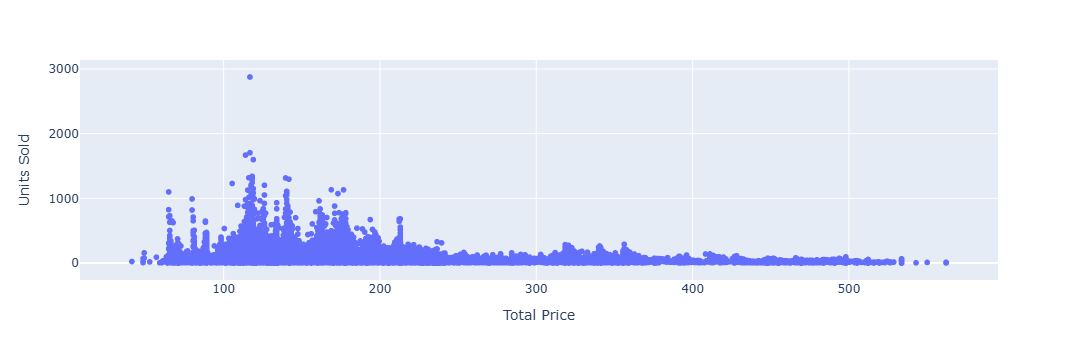

In [5]:
scatter(df_final, x="Total Price", y="Units Sold")

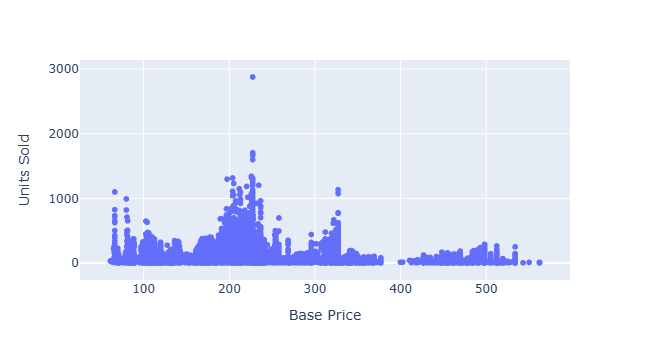

In [6]:
scatter(df_final, x="Base Price", y="Units Sold")

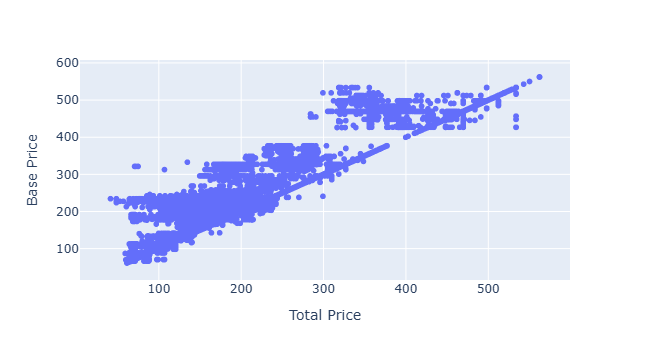

In [7]:
scatter(df_final, x="Total Price", y="Base Price")

The above scatter plots show the following:  
- Total Price and Base Price have a linear relationship, they are dependent on each other
- Demand is non-linear

Because of those, linear models will struggle with this dataset. A tree-based model is better suited here.

### Training

In [8]:
X = df_final[["Total Price", "Base Price"]]
y = df_final["Units Sold"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [10]:
regressor.score(X_test, y_test)

0.3764693086638463

In [11]:
for i in range(10):
    print(y_test.iloc[i], regressor.predict(X_test.iloc[i:i+1]))

41 [36.71321408]
13 [26.76732852]
339 [199.17021277]
14 [18.8235012]
4 [13.00574713]
49 [62.00578035]
61 [42.58403756]
35 [31.17906807]
24 [23.74468085]
23 [31.17906807]
